# NERP LTMP Fish Zoning — Dataset Meet & Greet

This notebook is a simple tour of `nerp_ltmp_fish_zoning.csv`. It covers what the columns mean,
basic coverage, missing values, and a few quick summaries.


## Quick facts (basic metadata)
- File: `nerp_ltmp_fish_zoning.csv` (~6.2 MB)
- Rows: 39,335 (each row = one species count for one reef/site/transect/date)
- Columns: 12
- Date range: 16-Nov-2011 to 05-May-2014
- Coverage: 56 reefs, 168 sites, 840 transects
- Species: 205
- Zoning values present: `C`, `O`
- Missingness: `LENGTH` is blank in ~87.6% of rows; `ABUNDANCE` has no blanks


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except Exception:
    sns = None

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)


In [2]:
DATA_PATH = Path.cwd() / 'nerp_ltmp_fish_zoning.csv'
df = pd.read_csv(DATA_PATH)
df.head()


,REEF_NAME,FULLREEF_ID,REEF_LAT,REEF_LONG,RAP_REEF_PAIR,SITE_NO,TRANSECT_NO,OPENORCLOSED_AFTER2004,SAMPLE_DATE,SPECIES,ABUNDANCE,LENGTH
0,20348S,20348S,-20.891667,150.958333,15,1,4,C,09-Dec-2013 00:00:00,Acanthurus blochii,2,NaN
1,20348S,20348S,-20.891667,150.958333,15,1,4,C,09-Dec-2013 00:00:00,Acanthurus dussumieri,12,NaN
2,20348S,20348S,-20.891667,150.958333,15,1,5,C,16-Jan-2012 00:00:00,Acanthurus dussumieri,12,NaN
3,20348S,20348S,-20.891667,150.958333,15,1,5,C,09-Dec-2013 00:00:00,Acanthurus nigricauda,2,NaN
4,20348S,20348S,-20.891667,150.958333,15,1,3,C,09-Dec-2013 00:00:00,Acanthurus pyroferus,1,NaN


## Structure at a glance
Each row is one species observation for one reef/site/transect/date.
Key fields: `REEF_NAME`, `SITE_NO`, `TRANSECT_NO`, `SAMPLE_DATE`, `SPECIES`, `ABUNDANCE`.
`ABUNDANCE` is the count; `LENGTH` is a size estimate when recorded.


## Column guide (plain language)
- `REEF_NAME`: reef code/name
- `FULLREEF_ID`: full reef identifier (often matches `REEF_NAME`)
- `REEF_LAT`, `REEF_LONG`: reef latitude/longitude
- `RAP_REEF_PAIR`: pairing code used to link reefs for comparisons
- `SITE_NO`: site number within the reef
- `TRANSECT_NO`: transect number within the site
- `OPENORCLOSED_AFTER2004`: zoning flag in the file (`C` or `O`)
- `SAMPLE_DATE`: survey date
- `SPECIES`: fish species (scientific name)
- `ABUNDANCE`: count of individuals for that species on that transect
- `LENGTH`: fish length estimate (often blank)


In [3]:
df.shape

df.columns


Index(['REEF_NAME', 'FULLREEF_ID', 'REEF_LAT', 'REEF_LONG', 'RAP_REEF_PAIR',
       'SITE_NO', 'TRANSECT_NO', 'OPENORCLOSED_AFTER2004', 'SAMPLE_DATE',
       'SPECIES', 'ABUNDANCE', 'LENGTH'],
      dtype='object')

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39335 entries, 0 to 39334
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   REEF_NAME               39335 non-null  object 
 1   FULLREEF_ID             39335 non-null  object 
 2   REEF_LAT                39335 non-null  float64
 3   REEF_LONG               39335 non-null  float64
 4   RAP_REEF_PAIR           39335 non-null  int64  
 5   SITE_NO                 39335 non-null  int64  
 6   TRANSECT_NO             39335 non-null  int64  
 7   OPENORCLOSED_AFTER2004  39335 non-null  object 
 8   SAMPLE_DATE             39335 non-null  object 
 9   SPECIES                 39335 non-null  object 
 10  ABUNDANCE               39335 non-null  int64  
 11  LENGTH                  4880 non-null   float64
dtypes: float64(3), int64(4), object(5)
memory usage: 3.6+ MB


## Missingness
Most rows have no `LENGTH` value; `ABUNDANCE` is complete.


In [5]:
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]


LENGTH    34455
dtype: int64

## Basic normalization and parsing
Make numeric fields numeric and parse `SAMPLE_DATE` as a date.


In [6]:
df['SAMPLE_DATE'] = pd.to_datetime(df['SAMPLE_DATE'], errors='coerce')
df['ABUNDANCE'] = pd.to_numeric(df['ABUNDANCE'], errors='coerce')
df['REEF_LAT'] = pd.to_numeric(df['REEF_LAT'], errors='coerce')
df['REEF_LONG'] = pd.to_numeric(df['REEF_LONG'], errors='coerce')
df['LENGTH'] = pd.to_numeric(df['LENGTH'], errors='coerce')

df[['SAMPLE_DATE','ABUNDANCE','REEF_LAT','REEF_LONG','LENGTH']].describe(include='all')


,SAMPLE_DATE,ABUNDANCE,REEF_LAT,REEF_LONG,LENGTH
count,39335,39335.000000,39335.000000,39335.000000,4880.000000
mean,2012-12-22 22:08:09.640269568,6.695081,-20.154749,149.689482,35.410246
min,2011-11-16 00:00:00,1.000000,-23.908333,145.833333,-1.000000
25%,2012-01-16 00:00:00,1.000000,-21.875000,147.000000,27.000000
50%,2012-04-24 00:00:00,2.000000,-20.991667,150.533333,34.000000
75%,2013-12-09 00:00:00,5.000000,-18.475000,152.366667,42.000000
max,2014-05-05 00:00:00,1614.000000,-16.050000,152.658333,145.000000
std,NaN,24.294925,2.224167,2.590532,12.831181


## Survey coverage
A survey is the combination of reef + site + transect + date.


In [7]:
survey_key = df[['REEF_NAME','SITE_NO','TRANSECT_NO','SAMPLE_DATE']].astype(str).agg('|'.join, axis=1)
summary = {
    'rows': len(df),
    'unique_species': df['SPECIES'].nunique(dropna=True),
    'unique_reefs': df['REEF_NAME'].nunique(dropna=True),
    'unique_sites': df[['REEF_NAME','SITE_NO']].drop_duplicates().shape[0],
    'unique_transects': df[['REEF_NAME','SITE_NO','TRANSECT_NO']].drop_duplicates().shape[0],
    'unique_surveys': survey_key.nunique(),
}
pd.Series(summary)


rows                39335
unique_species        205
unique_reefs           56
unique_sites          168
unique_transects      840
unique_surveys       1590
dtype: int64

In [8]:
date_summary = df['SAMPLE_DATE'].agg(['min','max'])
date_summary


min   2011-11-16
max   2014-05-05
Name: SAMPLE_DATE, dtype: datetime64[ns]

In [9]:
df['year'] = df['SAMPLE_DATE'].dt.year
year_counts = df['year'].value_counts().sort_index()
year_counts


year
2011     5369
2012    16090
2013     9066
2014     8810
Name: count, dtype: int64

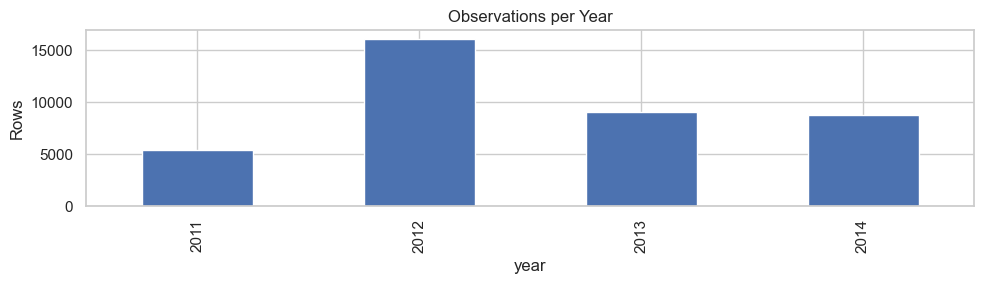

In [10]:
if len(year_counts) > 0:
    year_counts.plot(kind='bar', figsize=(10, 3), title='Observations per Year')
    plt.ylabel('Rows')
    plt.tight_layout()


## Species abundance overview
Quick look at the most common species and their counts.


In [11]:
abundance_summary = df['ABUNDANCE'].describe()
abundance_summary


count    39335.000000
mean         6.695081
std         24.294925
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max       1614.000000
Name: ABUNDANCE, dtype: float64

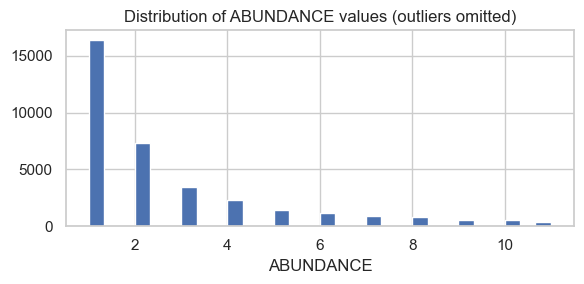

In [23]:
# outlier bounds with iqr
Q1 = df['ABUNDANCE'].quantile(0.25)
Q3 = df['ABUNDANCE'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

abundance_no_outliers = df['ABUNDANCE'][(df['ABUNDANCE'] >= lower_bound) & (df['ABUNDANCE'] <= upper_bound)]

abundance_no_outliers.hist(bins=30, figsize=(6, 3))
plt.title('Distribution of ABUNDANCE values (outliers omitted)')
plt.xlabel('ABUNDANCE')
plt.tight_layout()


In [25]:
# outliers that were omitted in the above hist
outliers = df['ABUNDANCE'][(df['ABUNDANCE'] < lower_bound) | (df['ABUNDANCE'] > upper_bound)]

print(f"Outlier bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Number of outliers: {len(outliers)} out of {len(df['ABUNDANCE'])} ({len(outliers)/len(df['ABUNDANCE'])*100:.1f}%)")
print(f"\nOutlier statistics:")
print(outliers.describe())
print(f"\nOutlier value range: {outliers.min():.0f} to {outliers.max():.0f}")


Outlier bounds: [-5.00, 11.00]
Number of outliers: 4128 out of 39335 (10.5%)

Outlier statistics:
count    4128.000000
mean       41.556686
std        64.971394
min        12.000000
25%        15.000000
50%        22.000000
75%        43.000000
max      1614.000000
Name: ABUNDANCE, dtype: float64

Outlier value range: 12 to 1614


In [24]:
top_species = (
    df.groupby('SPECIES')['ABUNDANCE']
    .sum()
    .sort_values(ascending=False)
    .head(30)
)
top_species


SPECIES
Pomacentrus lepidogenys          41229
Chromis nitida                   39329
Pomacentrus moluccensis          25590
Neopomacentrus azysron           15529
Pomacentrus coelestis            14862
Ctenochaetus spp                  9075
Pomacentrus wardi                 7090
Chlorurus sordidus                6127
Amblyglyphidodon curacao          5312
Pomacentrus bankanensis           4870
Acanthochromis polyacanthus       4732
Acanthurus nigrofuscus            4593
Pomacentrus brachialis            4497
Plectroglyphidodon lacrymatus     3816
Scarus psittacus                  3689
Scarus niger                      3203
Pomacentrus philippinus           3085
Chrysiptera rollandi              3055
Scarus globiceps                  3031
Scarus rivulatus                  2823
Chromis atripectoralis            2329
Pomacentrus amboinensis           2141
Chromis margaritifer              1965
Plectropomus leopardus            1911
Stegastes apicalis                1909
Scarus schlegeli 

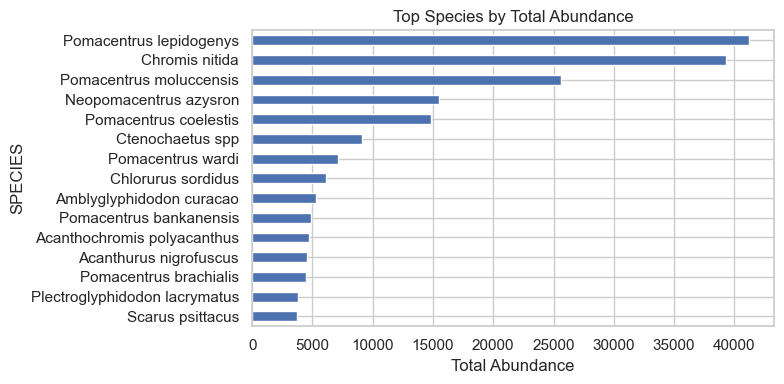

In [14]:
if len(top_species) > 0:
    top_species.sort_values().plot(kind='barh', figsize=(8, 4), title='Top Species by Total Abundance')
    plt.xlabel('Total Abundance')
    plt.tight_layout()


## Per-survey richness (species count)
Count how many species appear in each survey.


In [15]:
per_survey_richness = df.groupby(survey_key)['SPECIES'].nunique()
per_survey_richness.describe()


count    1590.000000
mean       23.313208
std         6.471316
min         1.000000
25%        19.000000
50%        24.000000
75%        28.000000
max        41.000000
Name: SPECIES, dtype: float64

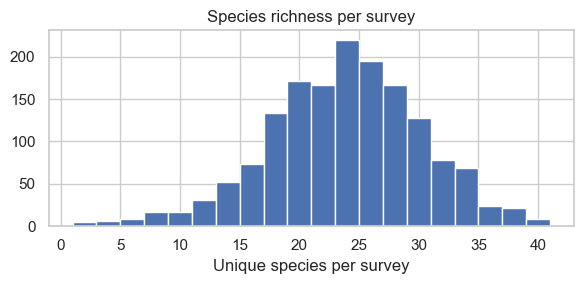

In [16]:
per_survey_richness.hist(bins=20, figsize=(6, 3))
plt.title('Species richness per survey')
plt.xlabel('Unique species per survey')
plt.tight_layout()


## Zoning context
Compare results between the two zoning flags (`C` vs `O`).


In [17]:
zone_summary = df.groupby('OPENORCLOSED_AFTER2004')['ABUNDANCE'].agg(['count','sum','mean'])
zone_summary


,count,sum,mean
OPENORCLOSED_AFTER2004,,,
C,20656,146928,7.113091
O,18679,116423,6.232828


## Duplicates
Check for repeated species entries within the same survey.


In [18]:
dup_mask = df.duplicated(subset=['REEF_NAME','SITE_NO','TRANSECT_NO','SAMPLE_DATE','SPECIES'])
dup_mask.sum()


np.int64(2267)

## Wide-format matrix for modeling
Pivot to a survey-by-species matrix and fill missing species with 0.


In [19]:
wide = df.pivot_table(
    index=['REEF_NAME','SITE_NO','TRANSECT_NO','SAMPLE_DATE'],
    columns='SPECIES',
    values='ABUNDANCE',
    aggfunc='sum',
    fill_value=0,
)
wide.shape


(1590, 205)

In [20]:
wide.head()


SPECIES                                    Acanthochromis polyacanthus  \
REEF_NAME SITE_NO TRANSECT_NO SAMPLE_DATE                                
20348S    1       1           2012-01-16                             0   
                              2013-12-09                             0   
                  2           2012-01-16                             0   
                              2013-12-09                             0   
                  3           2012-01-16                             0   

SPECIES                                    Acanthurus albipectoralis  \
REEF_NAME SITE_NO TRANSECT_NO SAMPLE_DATE                              
20348S    1       1           2012-01-16                           0   
                              2013-12-09                           0   
                  2           2012-01-16                           0   
                              2013-12-09                           0   
                  3           2012-01-16                           0   

SPECIES                                    Acanthurus auranticavus  \
REEF_NAME SITE_NO TRANSECT_NO SAMPLE_DATE                            
20348S    1       1           2012-01-16                         0   
                              2013-12-09                         0   
                  2           2012-01-16                         0   
                              2013-12-09                         0   
                  3           2012-01-16                         0   

SPECIES                                    Acanthurus blochii  \
REEF_NAME SITE_NO TRANSECT_NO SAMPLE_DATE                       
20348S    1       1           2012-01-16                    0   
                              2013-12-09                    0   
                  2           2012-01-16                    0   
                              2013-12-09                    0   
                  3           2012-01-16                    0   

SPECIES                                    Acanthurus dussumieri  \
REEF_NAME SITE_NO TRANSECT_NO SAMPLE_DATE                          
20348S    1       1           2012-01-16                       0   
                              2013-12-09                       0   
                  2           2012-01-16                       0   
                              2013-12-09                       0   
                  3           2012-01-16                       0   

SPECIES                                    Acanthurus grammoptilus  \
REEF_NAME SITE_NO TRANSECT_NO SAMPLE_DATE                            
20348S    1       1           2012-01-16                         0   
                              2013-12-09                         0   
                  2           2012-01-16                         0   
                              2013-12-09                         0   
                  3           2012-01-16                         0   

SPECIES                                    Acanthurus lineatus  \
REEF_NAME SITE_NO TRANSECT_NO SAMPLE_DATE                        
20348S    1       1           2012-01-16                     0   
                              2013-12-09                     0   
                  2           2012-01-16                     0   
                              2013-12-09                     0   
                  3           2012-01-16                     0   

SPECIES                                    Acanthurus mata  \
REEF_NAME SITE_NO TRANSECT_NO SAMPLE_DATE                    
20348S    1       1           2012-01-16                 0   
                              2013-12-09                 0   
                  2           2012-01-16                 0   
                              2013-12-09                 0   
                  3           2012-01-16                 0   

SPECIES                                    Acanthurus nigricans  \
REEF_NAME SITE_NO TRANSECT_NO SAMPLE_DATE                         
20348S    1       1          

## Notes for next steps
- Use `wide` as the modeling input table.
- Filter rare species or low-richness surveys if needed.
- For time trends, group by year/season or keep `SAMPLE_DATE`.
